## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2022_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,2010-01-01,37.991999,23.654887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,37.991999,23.654887,14643.0,NaN,37.991999,23.654887,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,2010-12-16,37.950174,23.650108,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,2010-01-01,37.991999,23.654887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,37.991999,23.654887,14292.0,14056.0,37.991999,23.654887,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,2010-01-16,37.950174,23.650108,47.880348,2010-01-09,2010-01-02,2010-12-16,2010-12-16,47.880348,47.880348
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,2010-01-01,38.009965,23.825567,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,2010-01-01,38.009965,23.825567,14545.0,14253.0,38.009965,23.825567,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,2010-12-16,38.050174,23.850109,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,2010-01-01,38.009965,23.825567,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,2010-01-16,38.009965,23.825567,14141.0,14041.0,38.009965,23.825567,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,2010-01-16,38.050174,23.850109,43.371546,2010-01-09,2010-01-02,2010-12-16,2010-12-16,43.371546,43.371546
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,2010-01-01,37.933609,23.731244,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,2010-01-01,37.933609,23.731244,14622.0,14349.0,37.933609,23.731244,14397.75,13992.857143,14356.300000,14154.3,14739.285714,14257.875000,14892.000000,14366.523810,2010-12-16,37.950174,23.750109,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000


In [6]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,αγιας βαρβαρας,αττικης,2010-05-01,0
1,αγιας βαρβαρας,αττικης,2010-05-16,0
2,αγιας βαρβαρας,αττικης,2010-06-01,0
3,αγιας βαρβαρας,αττικης,2010-06-16,0
4,αγιας βαρβαρας,αττικης,2010-07-01,0


In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.0,NaN,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14292.0,14056.0,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,47.880348,47.880348,47.880348
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.0,14253.0,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14141.0,14041.0,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,43.371546,43.371546,43.371546
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.0,14349.0,14397.75,13992.857143,14356.300000,14154.3,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000


In [10]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αγιας βαρβαρας,αττικης,2010-05-01,0
1,αγιας βαρβαρας,αττικης,2010-05-16,0
2,αγιας βαρβαρας,αττικης,2010-06-01,0
3,αγιας βαρβαρας,αττικης,2010-06-16,0
4,αγιας βαρβαρας,αττικης,2010-07-01,0


### Merge Timeline and WNV Case Files ###

In [11]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


['αθηναιων, δημοτικη κοινοτητα 1ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 2ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 3ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 4ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 5ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 6ου διαμερισματος δημου αθηναιων', 'αθηναιων, δημοτικη κοινοτητα 7ου διαμερισματος δημου αθηναιων', 'ηλιουπολεως', 'ηρακλειου αττικης', 'νικαιας αγιου ιωαννη ρεντη', 'πειραια', 'τροιζηνιας μεθανων']

Length: 12


In [12]:
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 1ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 2ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 3ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 4ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 5ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 6ου διαμερισματος δημου αθηναιων',''))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace(', δημοτικη κοινοτητα 7ου διαμερισματος δημου αθηναιων',''))

timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('ηλιουπολης','ηλιουπολεως'))
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('ηρακλειου','ηρακλειου αττικης'))
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('νικαιας αγιου ι. ρεντη','νικαιας αγιου ιωαννη ρεντη'))
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('πειραιως','πειραια'))
timeline_file['lau1'] = timeline_file['lau1'].apply(lambda x : x.replace('τροιζηνιας','τροιζηνιας μεθανων'))

In [13]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [14]:
wnv_file.case.sum()

296

In [15]:
wnv_file

,lau1,nuts2,dt_placement,case
0,αγιας βαρβαρας,αττικης,2010-05-01,0
1,αγιας βαρβαρας,αττικης,2010-05-16,0
2,αγιας βαρβαρας,αττικης,2010-06-01,0
3,αγιας βαρβαρας,αττικης,2010-06-16,0
4,αγιας βαρβαρας,αττικης,2010-07-01,0
...,...,...,...,...
9043,ωρωπου,αττικης,2022-08-16,0
9044,ωρωπου,αττικης,2022-09-01,0
9045,ωρωπου,αττικης,2022-09-16,0
9046,ωρωπου,αττικης,2022-10-01,0


In [16]:
wnv_file_grouped = wnv_file.groupby(['lau1', 'nuts2', 'dt_placement'], as_index = False)
wnv_file = wnv_file_grouped.sum()
wnv_file

,lau1,nuts2,dt_placement,case
0,αγιας βαρβαρας,αττικης,2010-05-01,0
1,αγιας βαρβαρας,αττικης,2010-05-16,0
2,αγιας βαρβαρας,αττικης,2010-06-01,0
3,αγιας βαρβαρας,αττικης,2010-06-16,0
4,αγιας βαρβαρας,αττικης,2010-07-01,0
...,...,...,...,...
8107,ωρωπου,αττικης,2022-08-16,0
8108,ωρωπου,αττικης,2022-09-01,0
8109,ωρωπου,αττικης,2022-09-16,0
8110,ωρωπου,αττικης,2022-10-01,0


In [17]:
wnv_file.case.sum()

296

In [18]:
merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [19]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.0,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000,NaN
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14292.0,14056.0,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,47.880348,47.880348,47.880348,NaN
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.0,14253.0,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000,NaN
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14141.0,14041.0,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,43.371546,43.371546,43.371546,NaN
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.0,14349.0,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84859,ωρωπου,αττικης,23.87488,38.22923,2022-12-16,2022,12,0.387549,0.140755,-0.303363,-0.140755,0.355095,0.133752,-0.282741,-0.133752,0.046561,0.039695,0.041071,0.039695,14347.0,13920.0,14124.307692,13790.428571,14276.181818,13818.444444,14253.700000,13753.000000,14812.400000,14098.125000,1013.245119,34.230381,36.132126,NaN
84860,ωρωπου,αττικης,23.87488,38.27415,2022-12-01,2022,12,0.286107,0.472441,-0.106509,-0.472441,0.235221,0.386516,-0.067131,-0.386516,0.046540,0.057328,0.028723,0.057328,14349.0,13908.0,14070.500000,13893.230769,14200.615385,13911.700000,14221.000000,13811.454545,14730.904762,14164.000000,977.112993,126.262493,169.060118,NaN
84861,ωρωπου,αττικης,23.87488,38.27415,2022-12-16,2022,12,0.453408,0.369145,-0.344484,-0.369145,0.457193,0.332110,-0.343422,-0.332110,0.016298,0.027777,0.019171,0.027777,14281.0,14169.0,14070.500000,13893.230769,14200.615385,13911.700000,14221.000000,13811.454545,14730.904762,14164.000000,1013.245119,34.230381,36.132126,NaN
84862,ωρωπου,αττικης,23.84632,38.20677,2022-12-01,2022,12,0.249513,-0.050919,-0.276136,0.050919,0.279034,-0.050602,-0.283650,0.050602,0.033366,0.028807,0.027995,0.028807,14406.0,13778.0,14169.818182,13778.133333,14285.000000,13826.500000,14339.888889,13730.111111,14896.904762,14130.058824,977.112993,126.262493,169.060118,NaN


In [20]:
merged = fillna(merged,{'case': 0})

In [21]:
merged['case'].value_counts()

0.0     83872
1.0       654
2.0       192
6.0        54
3.0        52
4.0        35
5.0         3
9.0         1
11.0        1
Name: case, dtype: int64

In [22]:
merged.case.sum()

1693.0

In [23]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2010-01-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000,0.0
1,2010-01-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2010.0,1.0,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000,0.0
2,2010-01-01,αγιου δημητριου,αττικης,23.730310,37.933570,2010.0,1.0,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000,0.0
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2010.0,1.0,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,0.000000,0.000000,0.000000,0.0
4,2010-01-01,αγκιστριου,αττικης,23.340090,37.695030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20587,2022-12-16,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2022.0,12.0,0.311134,0.172093,-0.267181,-0.172093,0.273675,0.155426,-0.244386,-0.155426,0.032497,0.021730,0.027345,0.021730,14388.000000,14246.000000,14126.733333,13924.937500,14387.636364,13976.357143,14458.777778,13907.812500,14918.823529,14314.857143,878.533587,64.381842,66.835793,0.0
20588,2022-12-16,φυλης,αττικης,23.672940,38.105580,2022.0,12.0,0.229914,0.080065,-0.175694,-0.080065,0.209037,0.092639,-0.151707,-0.092639,0.054137,0.051285,0.043086,0.051285,14322.250000,14038.500000,14073.461134,13844.457617,14293.844551,13879.225000,14291.370629,13776.013792,14853.395887,14204.923958,832.134717,42.456445,44.312617,0.0
20589,2022-12-16,χαλανδριου,αττικης,23.809410,38.022260,2022.0,12.0,0.200400,0.148692,-0.184211,-0.148692,0.218178,0.148194,-0.194554,-0.148194,0.045676,0.032925,0.029887,0.032925,14403.000000,14164.000000,14091.900000,13949.066667,14388.250000,13990.642857,14367.100000,13856.142857,14917.647059,14351.625000,930.487912,72.550454,75.314096,0.0
20590,2022-12-16,χαϊδαριου,αττικης,23.630840,38.009420,2022.0,12.0,0.320253,0.268085,-0.157603,-0.268085,0.343233,0.240475,-0.205532,-0.240475,0.048015,0.063077,0.058487,0.063077,14339.000000,14122.000000,14190.052632,13901.263158,14320.923077,13998.000000,14417.083333,13866.933333,14846.409091,14306.055556,839.945864,58.605859,61.133574,0.0


In [24]:
dataset.case.sum()

296.0

In [25]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset = dataset.astype({'case': 'int'})
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)
lau1_map = lau1_mapping(dataset, 0, 0)

In [26]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

### Add mosqutio predictions using trained model ###

In [27]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [28]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [29]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [30]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [31]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [32]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [33]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [34]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

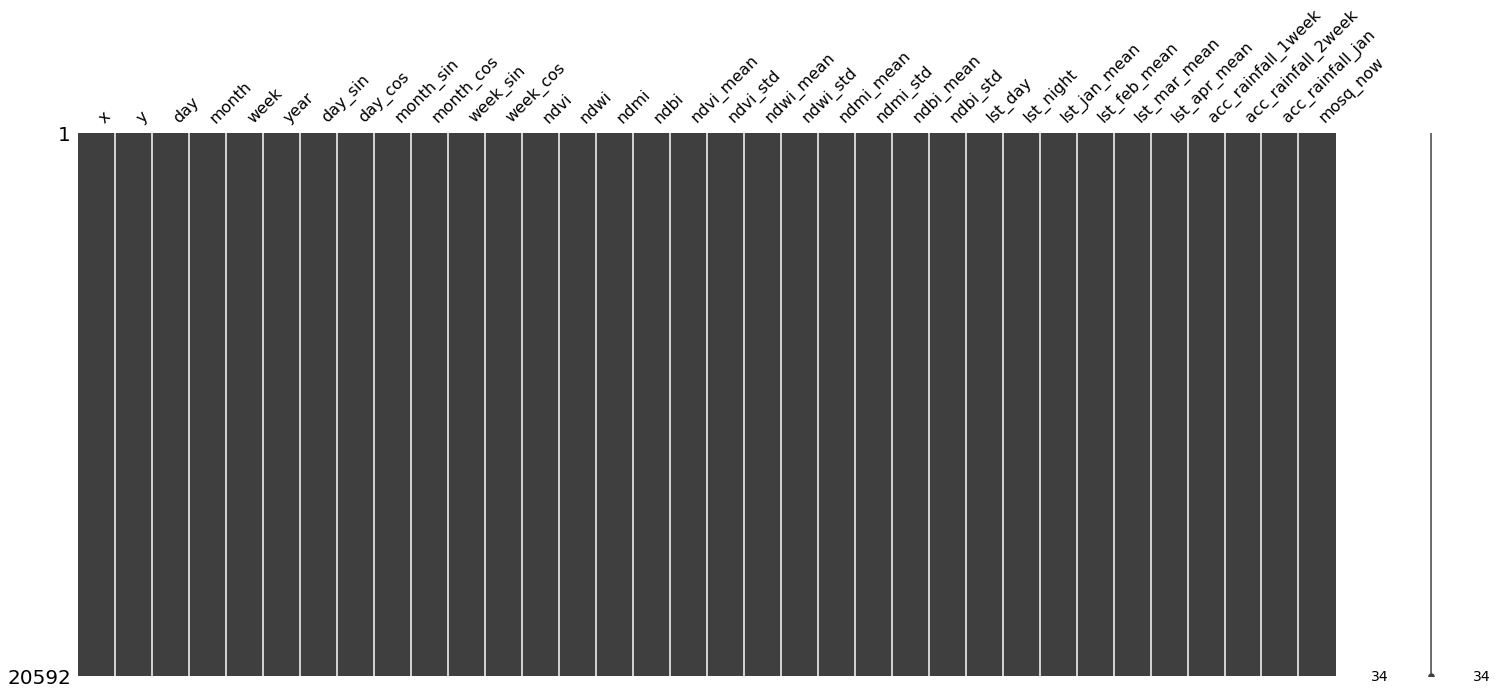

In [35]:
missingno.matrix(dataset_mamoth)

In [36]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [37]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [38]:
predictions = give_predictions(model, dataset_mamoth)

In [39]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.65697,37.99220,2010-01-01,178
1,23.82642,38.00806,2010-01-01,164
2,23.73031,37.93357,2010-01-01,221
3,23.71341,38.04721,2010-01-01,190
4,23.34009,37.69503,2010-01-01,206
...,...,...,...,...
20587,23.77628,38.01477,2022-12-16,4
20588,23.67294,38.10558,2022-12-16,3
20589,23.80941,38.02226,2022-12-16,3
20590,23.63084,38.00942,2022-12-16,3


<AxesSubplot:>

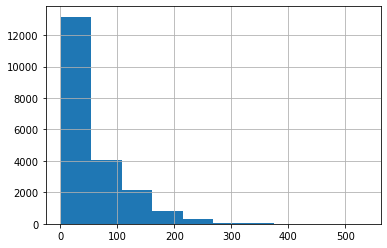

In [40]:
mosqutio_predictions.mosq_pred.hist()

In [41]:
#This cell writes the mosquito predictions to a seperate .csv file

# mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2022.csv', index = False)

In [42]:
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

mosqutio_predictions['x.approx'] = mosqutio_predictions['x'].apply(lambda x : round(x,5))
mosqutio_predictions['y.approx'] = mosqutio_predictions['y'].apply(lambda x : round(x,5))

In [43]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

In [44]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)

In [45]:
dataset.distance.max()

0.0

In [46]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [47]:
dataset.reset_index(inplace=True, drop=True)

<AxesSubplot:>

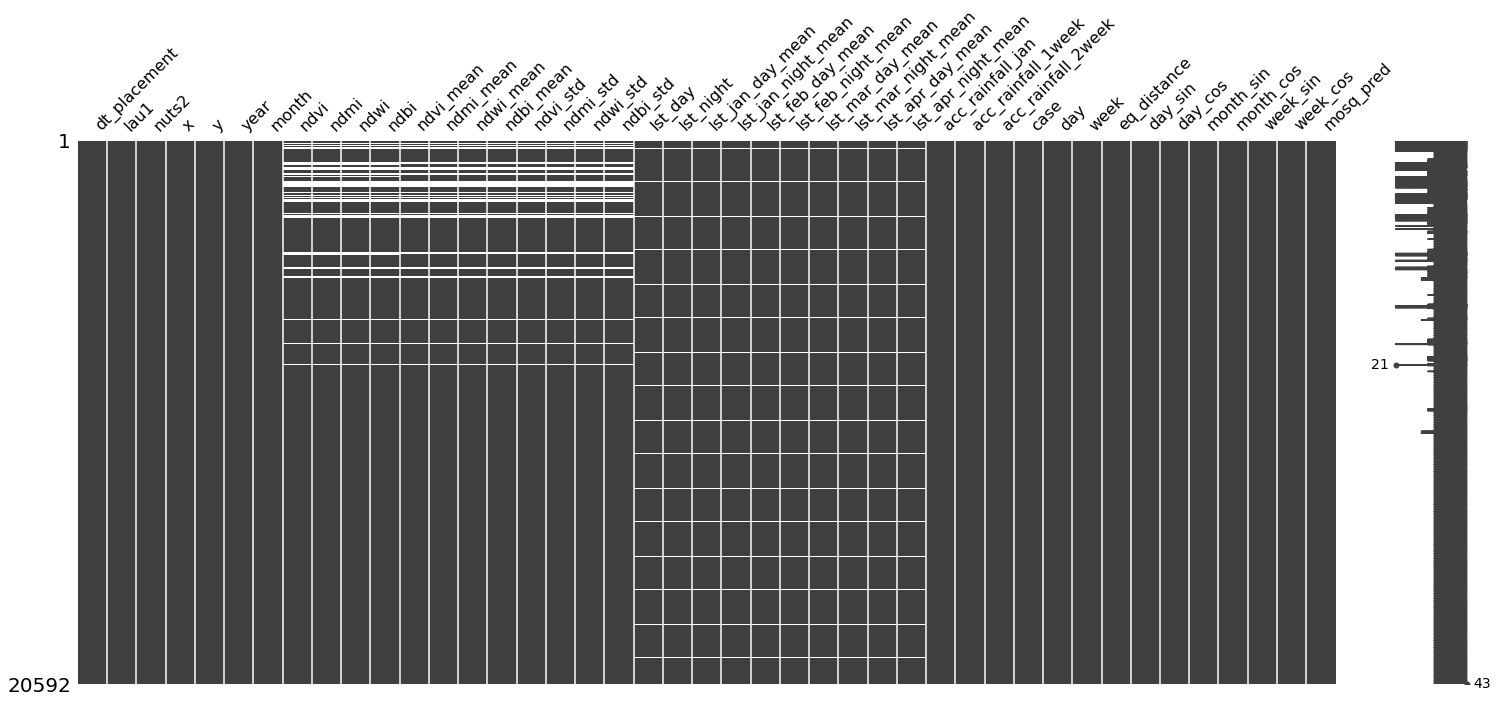

In [48]:
missingno.matrix(dataset)

### Adds demographic features ###

In [49]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [50]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [51]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [52]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [53]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας βαρβαρας,2.4,10925.9,26759.0
1,αγιας παρασκευης,7.9,7557.5,62157.0
2,αγιου δημητριου,5.0,14402.8,71747.0
3,αγιων αναργυρων καματερου,9.2,6833.8,61427.0
4,αγκιστριου,13.4,85.2,1107.0
...,...,...,...,...
61,φιλοθεης ψυχικου,6.1,4421.0,27400.0
62,φυλης,109.1,421.2,48255.0
63,χαϊδαριου,22.7,2069.6,46983.0
64,χαλανδριου,10.8,6869.6,77118.0


In [54]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ηλιουπολεως', 'ηρακλειου αττικης', 'φιλαδελφειας χαλκηδονος']

Length: 3


In [55]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηλιουπολης','ηλιουπολεως'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρακλειου','ηρακλειου αττικης'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('νεας φιλαδελφειας νεας χαλκηδονας','φιλαδελφειας χαλκηδονος'))


In [56]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [57]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

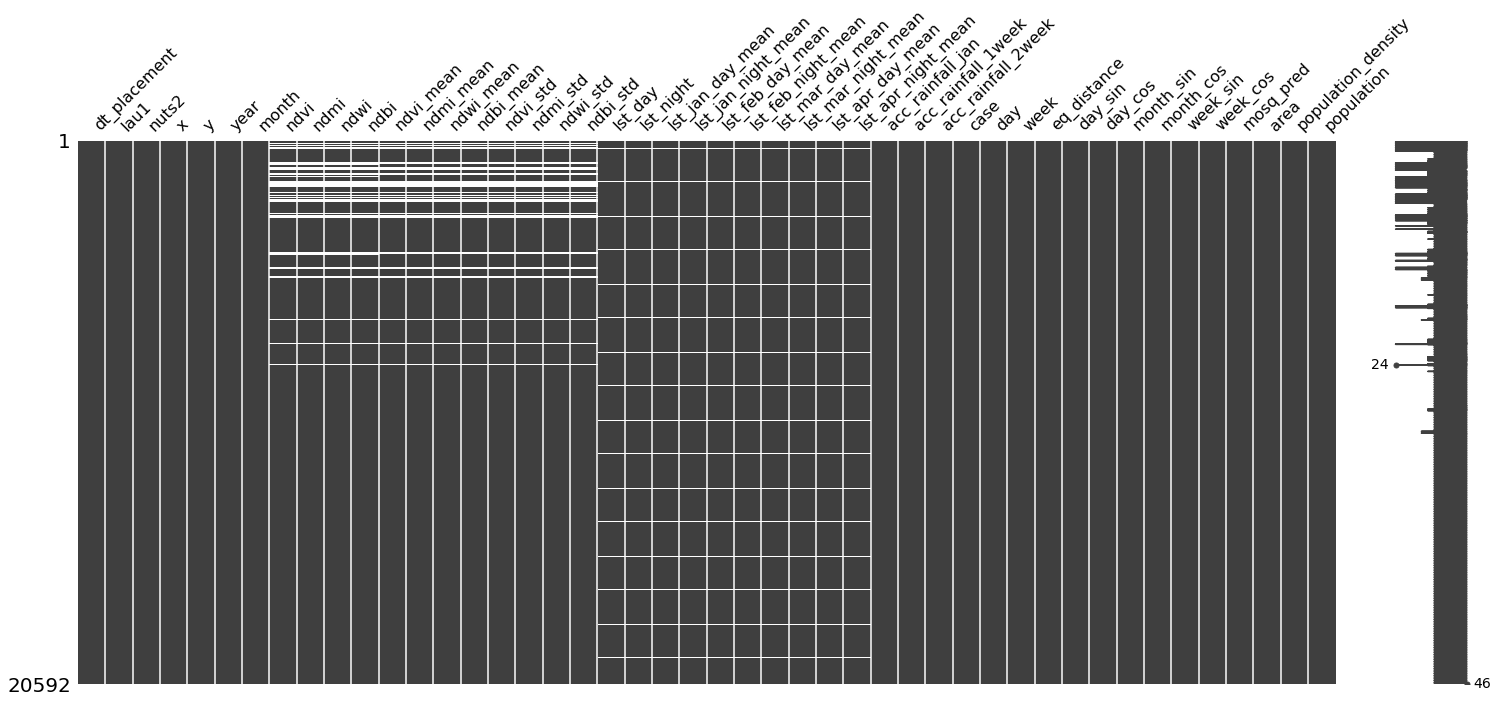

In [58]:
missingno.matrix(dataset)

In [59]:
missing = describe_dataframe(dataset)

In [60]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,area,population_density,population
0,2010-01-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000,0,1,53,44.75555,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,178,2.4,10925.9,26759.0
1,2010-01-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000,0,1,53,44.85879,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,164,7.9,7557.5,62157.0
2,2010-01-01,αγιου δημητριου,αττικης,23.73031,37.93357,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000,0,1,53,44.74465,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,221,5.0,14402.8,71747.0
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2010,1,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,0.000000,0.000000,0.000000,0,1,53,44.83209,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,190,9.2,6833.8,61427.0
4,2010-01-01,αγκιστριου,αττικης,23.34009,37.69503,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,0.000000,0.000000,0.000000,0,1,53,44.33593,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,206,13.4,85.2,1107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20587,2022-12-16,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2022,12,0.311134,0.172093,-0.267181,-0.172093,0.273675,0.155426,-0.244386,-0.155426,0.032497,0.021730,0.027345,0.021730,14388.000000,14246.000000,14126.733333,13924.937500,14387.636364,13976.357143,14458.777778,13907.812500,14918.823529,14314.857143,878.533587,64.381842,66.835793,0,16,50,44.83787,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,4,6.1,4421.0,27400.0
20588,2022-12-16,φυλης,αττικης,23.67294,38.10558,2022,12,0.229914,0.080065,-0.175694,-0.080065,0.209037,0.092639,-0.151707,-0.092639,0.054137,0.051285,0.043086,0.051285,14322.250000,14038.500000,14073.461134,13844.457617,14293.844551,13879.225000,14291.370629,13776.013792,14853.395887,14204.923958,832.134717,42.456445,44.312617,0,16,50,44.86026,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,3,109.1,421.2,48255.0
20589,2022-12-16,χαλανδριου,αττικης,23.80941,38.02226,2022,12,0.200400,0.148692,-0.184211,-0.148692,0.218178,0.148194,-0.194554,-0.148194,0.045676,0.032925,0.029887,0.032925,14403.000000,14164.000000,14091.900000,13949.066667,14388.250000,13990.642857,14367.100000,13856.142857,14917.647059,14351.625000,930.487912,72.550454,75.314096,0,16,50,44.86179,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,3,10.8,6869

In [61]:
dataset = calculate_mosq_previous(dataset)

In [62]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

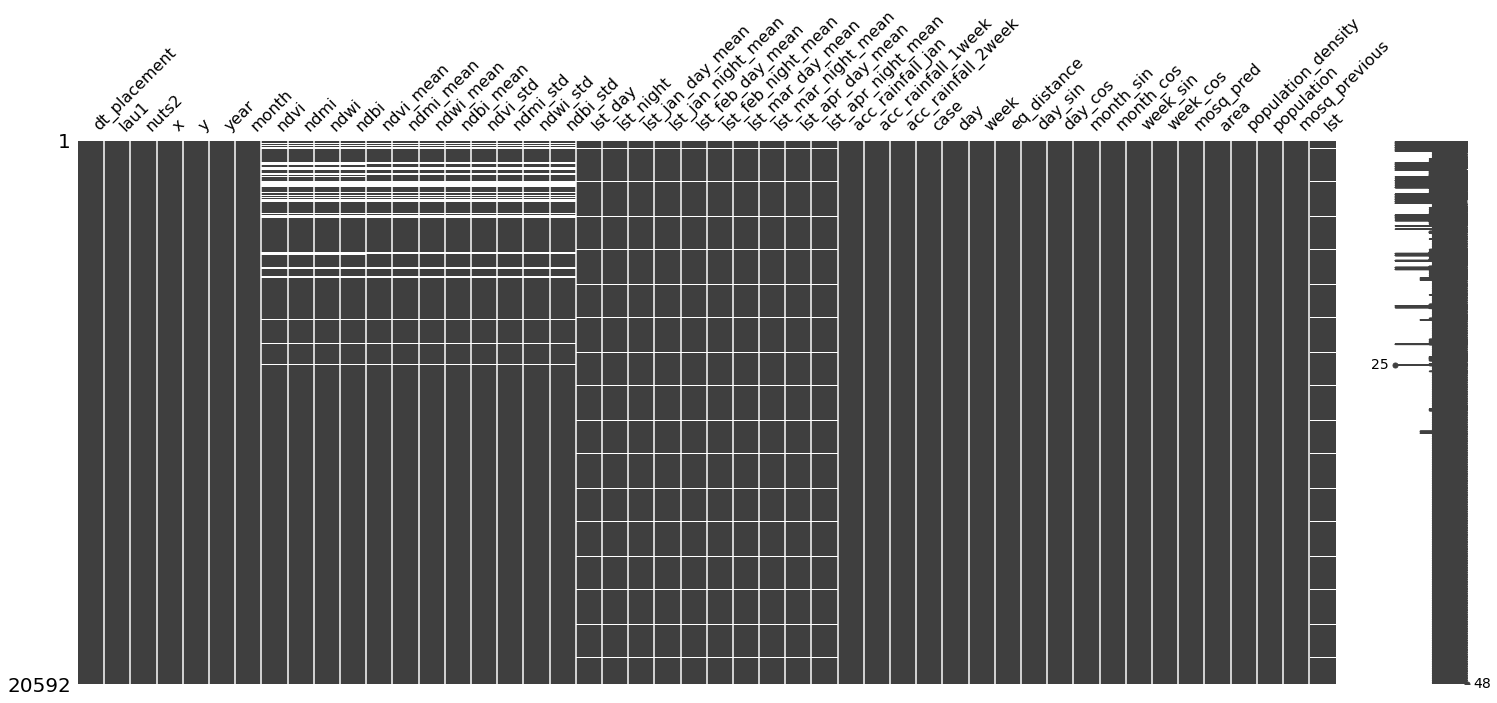

In [63]:
missingno.matrix(dataset)

In [64]:
dataset['case'].value_counts()

0     20413
1       125
2        28
3        12
4         5
6         4
5         3
11        1
9         1
Name: case, dtype: int64

In [65]:
dataset.case.sum()

296

In [66]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [67]:
dataset = convert_multiple_cases(dataset)

In [68]:
dataset['case'].value_counts()

0    20413
1      296
Name: case, dtype: int64

In [69]:
dataset.case.sum()

296

In [70]:
cols = dataset.columns

In [71]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'mosq_pred', 'area',
       'population_density', 'population', 'mosq_previous', 'lst'],
      dtype='object')

In [72]:
len(cols)

48

In [73]:
# check columns

In [74]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [75]:
len(rearranged_columns)

48

In [76]:
dataset = dataset[rearranged_columns].copy()

In [77]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482000,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.0,0.000000,0.000000,178,0,0
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890000,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.0,0.000000,0.000000,164,0,0
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805000,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.0,0.000000,0.000000,221,0,0
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010000,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.0,0.000000,0.000000,190,0,0
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615000,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,0.0,0.000000,0.000000,206,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20704,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,12.101125,592.518341,77,357,1
20705,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,12.101125,592.518341,77,357,1
20706,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,12.101125,592.518341,77,357,1
20707,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438

### Add geomorphological features ###

In [78]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [79]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 6.802114029266602


In [80]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [81]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.0,0.0,0.0,178,0,0,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.0,0.0,0.0,164,0,0,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.0,0.0,0.0,221,0,0,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.0,0.0,0.0,190,0,0,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,0.0,0.0,0.0,206,0,0,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489


<AxesSubplot:>

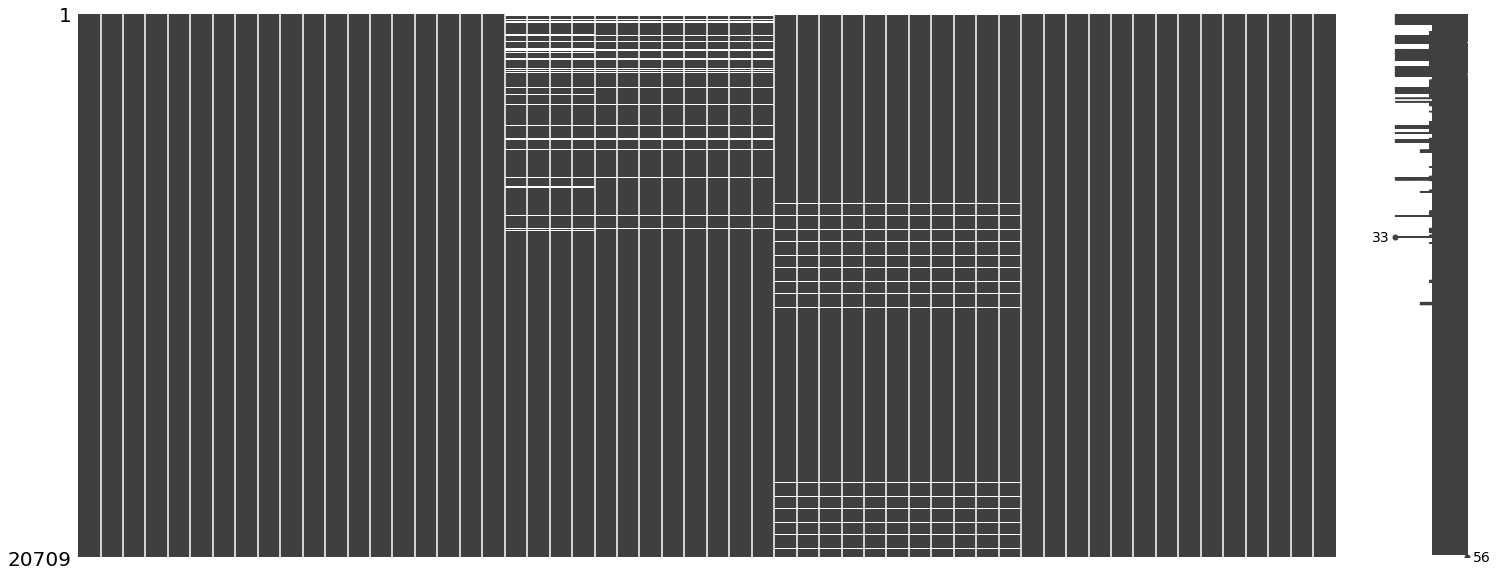

In [82]:
missingno.matrix(dataset)

In [83]:
cols = dataset.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'mosq_previous', 'case', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m'],
      dtype='object')

In [84]:
len(cols)

56

In [85]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [86]:
len(rearranged_columns)

56

In [87]:
dataset = dataset[rearranged_columns]

### Add Landcover features ###

In [88]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [89]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [90]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [91]:
data_years = dataset['year'].unique().tolist()

In [92]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [93]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2010
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2011
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2012
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2013
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2014
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2015
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2016
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2017
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2018
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2019
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2020
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2021
Min distance: 0.0
Max distance: 6.802114029266602
Year: 2022
Min distance: 0.0
Max distance: 6.802114029266602


In [94]:
dataset_final = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

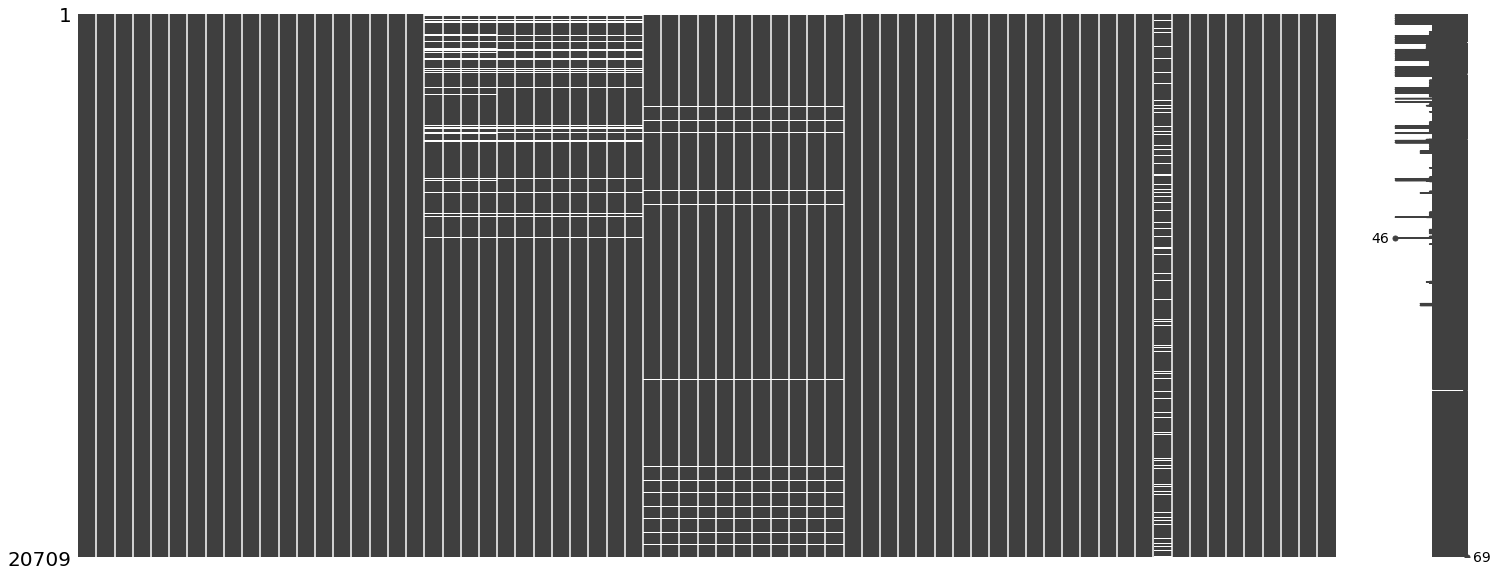

In [95]:
missingno.matrix(dataset_final)

In [96]:
cols = dataset_final.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case',
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment',
       'lc_prop3', 'lc_prop3_assessment', '

In [97]:
len(cols)

69

In [98]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 
       'lc_prop3', 'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_type3', 
       'lc_type4', 'lc_type5', 'lw', 'qc', 'mosq_pred', 'mosq_previous', 'case']

In [99]:
len(rearranged)

69

In [100]:
dataset_final = dataset_final[rearranged]

In [101]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2022.csv", encoding = enc, index = False)